<img src="../../figs/holberton_logo.png" alt="logo" width="500"/>

# Twitter Sentiment Analysis 

## Executive Summary

- **Natural Language Processing (NLP)**: The discipline of computer science, artificial intelligence and linguistics that is concerned with the creation of computational models that process and understand natural language. These include: making the computer understand the semantic grouping of words (e.g. cat and dog are semantically more similar than cat and spoon), text to speech, language translation and many more


- **Sentiment Analysis**: It is the interpretation and classification of emotions (positive, negative and neutral) within text data using text analysis techniques. Sentiment analysis allows organizations to identify public sentiment towards certain words or topics.


In this notebook, we will analyze a dataset containing `1.6 million tweets` and develop a **Sentiment Analysis model to categorize a tweet as `Positive` or `Negative`.**

## Key Steps

### Exploratory Data Analysis (EDA):

- **Preprocessing**: Prepare the data by removing duplicates, handling missing values, and addressing any inconsistencies.


- **Understanding Target Values**: Analyze the distribution of positive, negative, and neutral sentiments to understand the dataset's balance.


- **Understanding Tweet Statistics**: Calculate basic statistics such as average tweet length, most common words, and sentiments associated with certain keywords.


### Data Cleaning:

- **Dropping Unnecessary Columns**: Remove columns that are not needed for sentiment analysis to simplify the dataset.


- **Removing Stopwords and Punctuation**: Eliminate common words like "and," "the," and punctuation marks that don't contribute much to sentiment understanding.


- **Content Cleaning**: Normalize text by converting to lowercase, removing special characters, and handling mentions or hashtags.


### Data Preparation:

- **Tokenization**: Convert the cleaned text into individual words or tokens for analysis.


- **Word Embeddings**: Utilize pre-trained word embeddings (e.g., Word2Vec, GloVe) to represent words as dense vectors, capturing semantic meaning.


### Building LSTM Model:

Long Short-Term Memory (LSTM): Construct a deep learning model, such as an LSTM, which is well-suited for sequential data like text due to its ability to remember context over long sequences.


### Training, Testing, and Validation:

- **Training**: Train the LSTM model on the preprocessed and embedded data using labeled sentiment classes.


- **Testing**: Evaluate the model's performance on a separate test dataset to assess its ability to classify sentiments accurately.


- **Validation**: Utilize a validation dataset during training to monitor the model's performance and prevent overfitting.


The process involves exploring and preparing the data, cleaning it to remove noise, creating a model-ready dataset, building an LSTM model for sentiment analysis, and rigorously training, testing, and validating the model to ensure its reliability and generalization to new data.


## Importing Libraries and Tools

Importing the necessary libraries and tools is the foundational step in our data analysis and modeling journey. `TensorFlow` empowers us to build deep learning models, while `NLTK` provides advanced natural language processing capabilities. 

These libraries enable efficient data processing, transformation, and visualization, fostering insights from raw text. 

With `Pandas` and `NumPy`, we manipulate data with ease, ensuring its readiness for analysis. 


`Matplotlib` and `Seaborn` enhance our ability to visually comprehend trends and patterns in the data. 

In [1]:
# Data Processing and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Building and Accuracy Measures
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, Embedding, Flatten, Conv1D, MaxPooling1D, LSTM
from keras import utils
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.optimizers import Adam

# Tensorflow and NLTK
import tensorflow as tf
import nltk 
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Other Utilities
import re
import os
from wordcloud import WordCloud, STOPWORDS
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\evisp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us to get to know the data before diving deep. Here's what we do:

- **Data Reading**: We start by loading the dataset to see its contents.


- **Missing Values Check**: We examine each part to ensure there are no gaps or emptiness.


- **Target Assessment**: We analyze how many instances fall into each sentiment category — positive or negative


- **Tweet Length Analysis**: We assess the length of tweets to understand their structure and content.


- **Common Phrases Identification**: We identify frequently occurring words and phrases, helping us uncover significant themes.

### Data Reading

In [2]:
data = pd.read_csv('../../data/twitterdataset.csv', encoding = 'latin', header=None)
data.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


By looking at the top part of the dataset we can learn a lot from it. We can indicate which column refers to. Therefore, we can describe them briefly:

- `0` : target of sentiment


- `1` : id of user


- `2` : date of tweet


- `3` : unnecessary column, in each row contains 'NO_QUERY'


- `4` : nickname of author


- `5` : content of tweet

### Renaming column names

To enhance convenience during analysis, we're considering renaming the numerical column names to predefined, more descriptive names. This adjustment will make working with the dataset smoother and more intuitive.

In [3]:
data = data.rename(columns={0: 'target', 1: 'id', 2: 'date', 3: 'query', 4: 'username', 5: 'content'})
data.head()

,target,id,date,query,username,content
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


### Missing values

It's common to have some data missing in datasets. So, it's a good practice to look for missing values before starting any analysis. This helps ensure accurate and reliable results

We can create a **heatmap** of missing values, or check them **numerically**

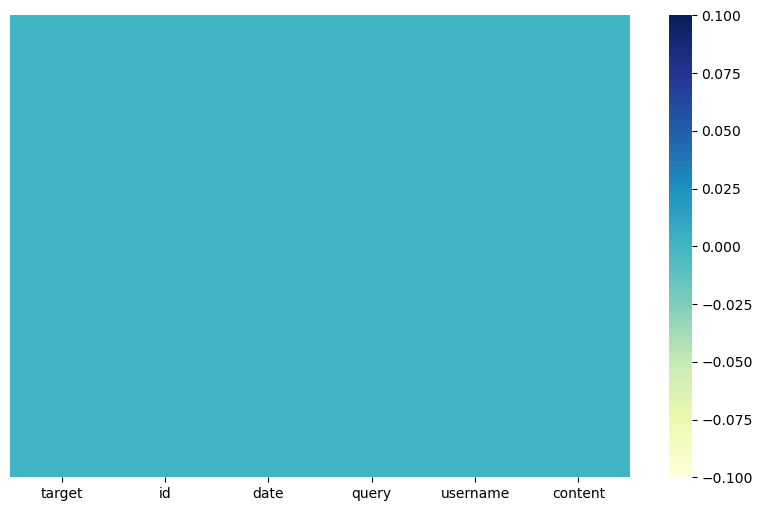

In [4]:
# Create a heatmap of missing values
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cmap="YlGnBu")
plt.yticks([])
plt.show()

In [5]:
missing_data = data.isna().sum().sort_values(ascending=False)
percentage_missing = round((data.isnull().sum()/data.isnull().count()).sort_values(ascending=False)*100,2)
missing_info = pd.concat([missing_data,percentage_missing],keys=['Missing values','Percentage'],axis=1)
missing_info

,Missing values,Percentage
target,0,0.0
id,0,0.0
date,0,0.0
query,0,0.0
username,0,0.0
content,0,0.0


Fortunately, dataset is free of missing values.

### Targets

Firstly let's see what the classes of the individual tweets are about. We're enhancing data display settings to accommodate longer text entries. Then, we're examining specific data rows linked to a particular target value, aiming to understand the content associated with it. This approach provides a closer look at the information within the dataset, aiding analysis

In [6]:
possible_target_values = data['target'].unique()
print(possible_target_values)

[0 4]


In [10]:
#pd.set_option('display.max_colwidth', -1)
data[data['target']==0]['content'].head()

0    @switchfoot http://twitpic.com/2y1zl - Awww, t...
1    is upset that he can't update his Facebook by ...
2    @Kenichan I dived many times for the ball. Man...
3      my whole body feels itchy and like its on fire 
4    @nationwideclass no, it's not behaving at all....
Name: content, dtype: object

By reading the content of the tweets, we can conclude that they have a rather negative message, so class 0 refers to negative sentiments tweets.

In [11]:
data[data['target']==4]['content'].head()

800000         I LOVE @Health4UandPets u guys r the best!! 
800001    im meeting up with one of my besties tonight! ...
800002    @DaRealSunisaKim Thanks for the Twitter add, S...
800003    Being sick can be really cheap when it hurts t...
800004      @LovesBrooklyn2 he has that effect on everyone 
Name: content, dtype: object

By reading the content of the tweets, we can conclude that they have a rather positive message, so class 4 refers to positive sentiments tweets.

#### Replacing Values in "target" Column

Here, we're modifying the values in the "`target`" column. Specifically, we're changing certain numerical values to corresponding textual labels. This replacement creates a more interpretable representation of sentiments, making the data more understandable and user-friendly.

In [12]:
data['target'] = data['target'].replace([0, 4],['Negative','Positive'])

#### Understanding Target Value

We check the number of tweets containing a `positive` sentiment versus the number of tweets containing a `negative` sentiment

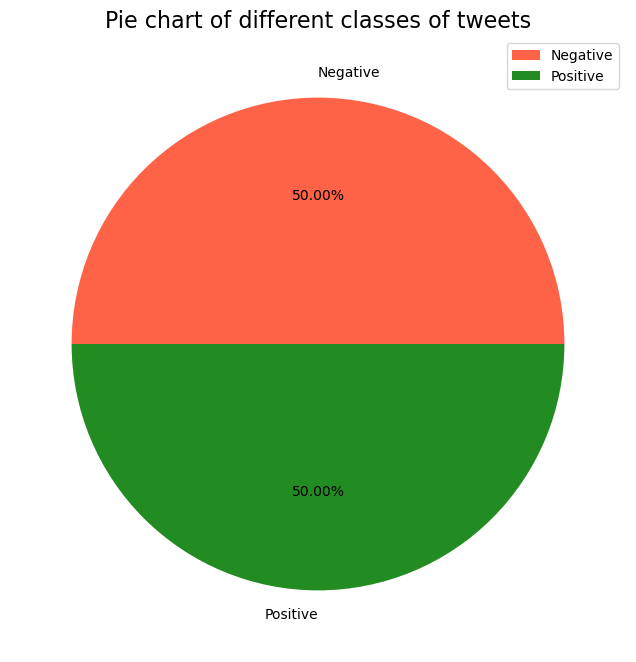

In [13]:
fig = plt.figure(figsize=(8,8))

targets = data.groupby('target').size()

targets.plot(kind='pie', subplots=True, figsize=(10, 8), autopct = "%.2f%%", colors=['#FF6347','#228B22'])

plt.title("Pie chart of different classes of tweets",fontsize=16)
plt.ylabel("")
plt.legend()
plt.show()

In [14]:
data['target'].value_counts()

target
Negative    800000
Positive    800000
Name: count, dtype: int64

As we can see dataset is perfectly balanced with the same numbers of occurrences for both classes. It is also worth mentioning that the data is not skewed which will certainly make modeling easier.

### Length of tweet content

Based on this analysis, we can find out the length of tweets for two particular classes of tweets.

Looking at how long tweets are is valuable because it helps us distinguish between two specific groups of tweets. By comparing the lengths of tweets in these groups, we can uncover potential patterns or insights that might relate to their distinct characteristics. This analysis contributes to a better understanding of how tweet length might be connected to the way people express their feelings.

In [15]:
data['length'] = data.content.str.split().apply(len)
data.head()

,target,id,date,query,username,content,length
0,Negative,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",19
1,Negative,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,21
2,Negative,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,18
3,Negative,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,10
4,Negative,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",21


Adding new column to dataset with length of particular tweets.

### Distribution Analysis of Positive Sentiment Tweet Length

The goal is to visually explore the distribution of text lengths in positive sentiment tweets. This helps to gain an understanding of how the length of text varies in tweets with positive sentiment, enhancing our comprehension of tweet dynamics. We create two parts, side by side


- **Histogram**: The first part (left) displays a histogram with green bars representing the distribution of tweet lengths for positive sentiment tweets.


- **Summary Table**: The second part (right) shows a table with summary statistics about the tweet lengths, such as mean, median, minimum, and maximum. This information provides insights into the spread of text lengths for positive sentiment tweets.

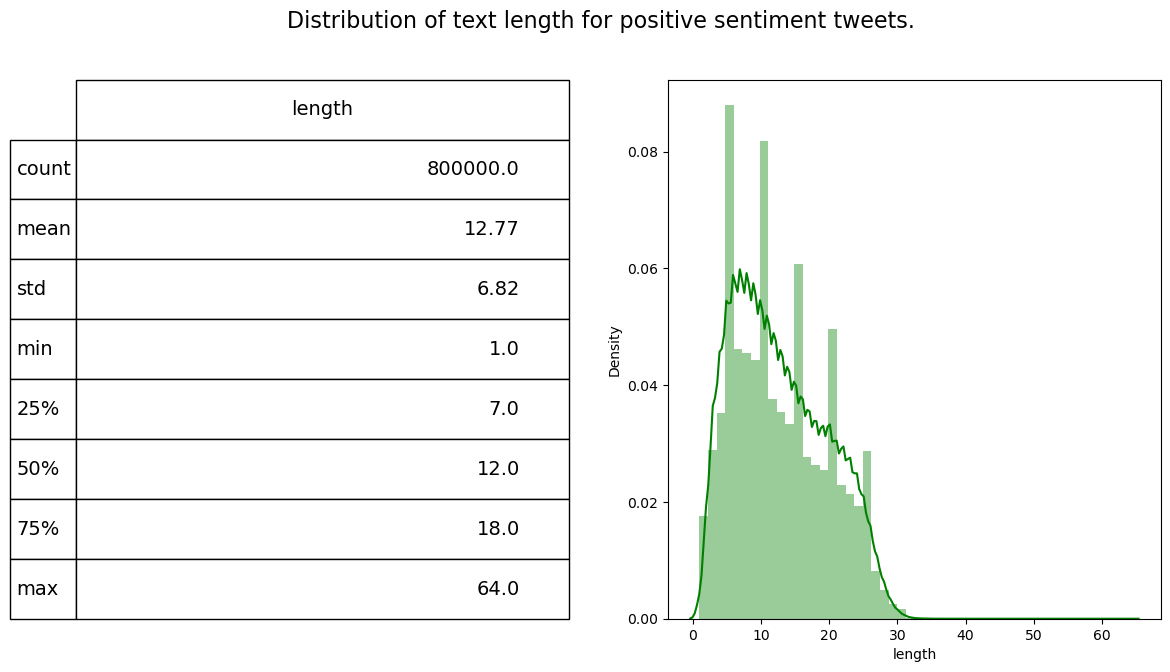

In [16]:
fig = plt.figure(figsize=(14,7))

ax1 = fig.add_subplot(122)
sns.distplot(data[data['target']=='Positive']['length'], ax=ax1,color='green')

describe = data.length[data.target=='Positive'].describe().to_frame().round(2)
ax2 = fig.add_subplot(121)
ax2.axis('off')
font_size = 14
bbox = [0, 0, 1, 1]
table = ax2.table(cellText = describe.values, rowLabels = describe.index, bbox=bbox, colLabels=describe.columns)
table.set_fontsize(font_size)
fig.suptitle('Distribution of text length for positive sentiment tweets.', fontsize=16)

plt.show()

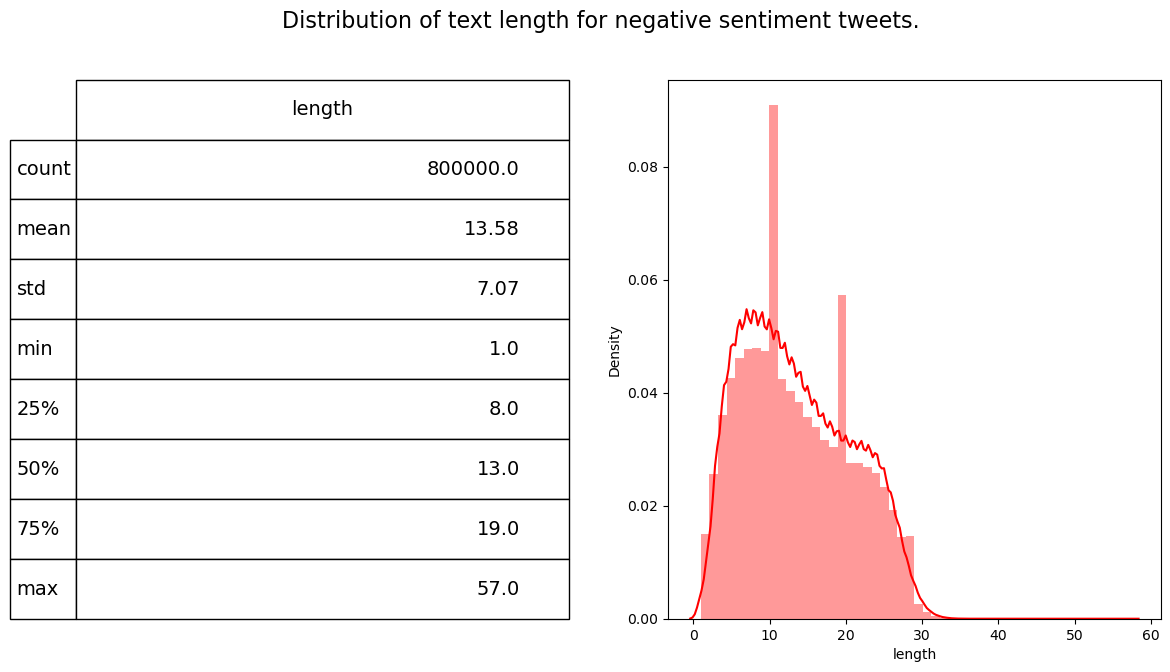

In [17]:
fig = plt.figure(figsize=(14,7))

ax1 = fig.add_subplot(122)
sns.distplot(data[data['target']=='Negative']['length'], ax=ax1,color='red')
describe = data.length[data.target=='Negative'].describe().to_frame().round(2)

ax2 = fig.add_subplot(121)
ax2.axis('off')
font_size = 14
bbox = [0, 0, 1, 1]
table = ax2.table(cellText = describe.values, rowLabels = describe.index, bbox=bbox, colLabels=describe.columns)
table.set_fontsize(font_size)
fig.suptitle('Distribution of text length for negative sentiment tweets.', fontsize=16)

plt.show()

In such a large dataset, tweets belonging to two classes are almost the same lengths. However, the average tweet length for the negative class is about 0.8 words longer.

### Most commonly tweeting users

This code generates a bar plot showcasing the top `10` users who often publish positive tweets. The purpose is to identify and visualize the most active contributors to positive sentiment content. 

The y-axis reflects the frequency of positive tweets published by these users. By observing this information, we can discern the individuals who are prominent in spreading positivity on the platform.

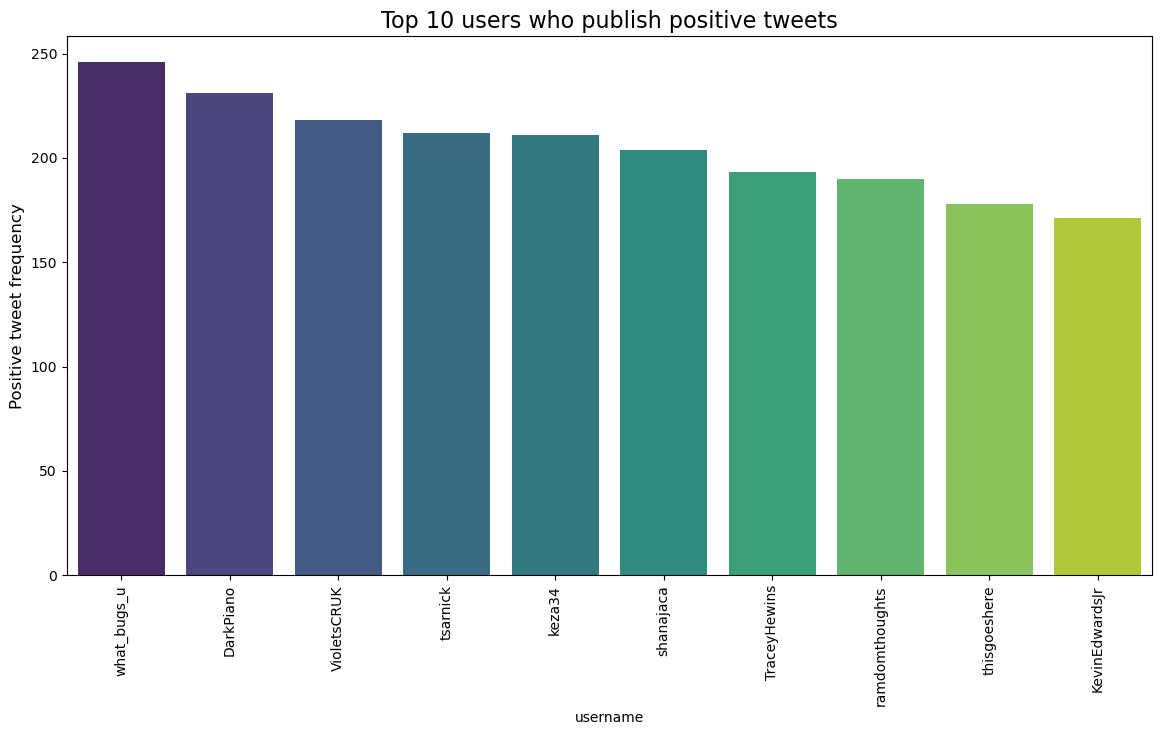

In [18]:
plt.figure(figsize=(14,7))

common_keyword=sns.barplot(x=data[data['target']=='Positive']['username'].value_counts()[:10].index,
                           y=data[data['target']=='Positive']['username'].value_counts()[:10],
                           palette='viridis')

common_keyword.set_xticklabels(common_keyword.get_xticklabels(),rotation=90)
common_keyword.set_ylabel('Positive tweet frequency',fontsize=12)

plt.title('Top 10 users who publish positive tweets',fontsize=16)
plt.show()

Seems like `what_bugs_u` is kind of a user who is in good mood really often.

In [19]:
data[data['username']=='what_bugs_u'].head()

,target,id,date,query,username,content,length
1141441,Positive,1977182027,Sat May 30 20:18:46 PDT 2009,NO_QUERY,what_bugs_u,@JadeMcCray why limit your story to 140 chr. T...,22
1141626,Positive,1977198277,Sat May 30 20:21:22 PDT 2009,NO_QUERY,what_bugs_u,@cadmiumcannibal why limit your story to 140 c...,22
1141648,Positive,1977207353,Sat May 30 20:22:52 PDT 2009,NO_QUERY,what_bugs_u,@RonanDosSantos why limit your story to 140 ch...,22
1141674,Positive,1977208245,Sat May 30 20:23:01 PDT 2009,NO_QUERY,what_bugs_u,@ShayMac28 why limit your story to 140 chr. Te...,22
1142667,Positive,1977331498,Sat May 30 20:43:12 PDT 2009,NO_QUERY,what_bugs_u,@lynnsdecor why limit your story to 140 chr. T...,22


Based on the contet posted by the user, it can be concluded that this is not a regular user but it is just a bot.

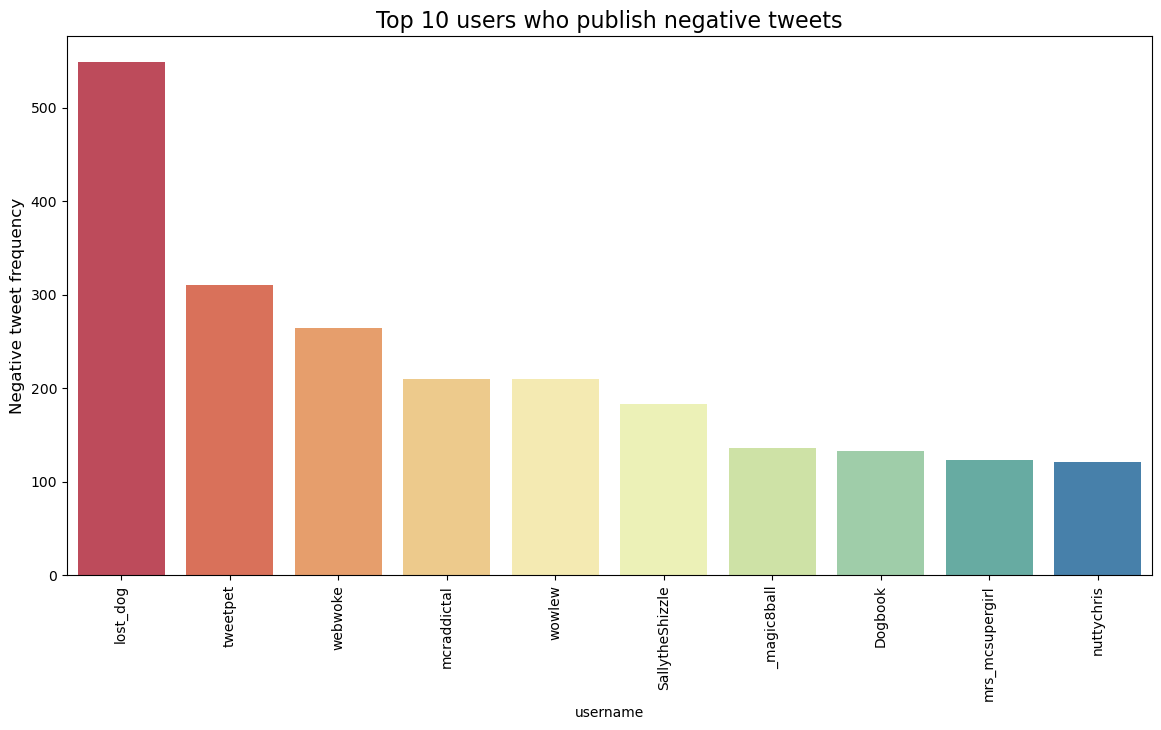

In [20]:
plt.figure(figsize=(14,7))

common_keyword=sns.barplot(x=data[data['target']=='Negative']['username'].value_counts()[:10].index,
                           y=data[data['target']=='Negative']['username'].value_counts()[:10],
                           palette='Spectral')

common_keyword.set_xticklabels(common_keyword.get_xticklabels(),rotation=90)
common_keyword.set_ylabel('Negative tweet frequency',fontsize=12)

plt.title('Top 10 users who publish negative tweets',fontsize=16)
plt.show()

In [21]:
data[data['username']=='lost_dog'].head()

,target,id,date,query,username,content,length
43935,Negative,1676704158,Fri May 01 22:54:02 PDT 2009,NO_QUERY,lost_dog,@NyleW I am lost. Please help me find a good h...,11
45574,Negative,1677189389,Sat May 02 00:51:35 PDT 2009,NO_QUERY,lost_dog,@SallyD I am lost. Please help me find a good ...,11
46919,Negative,1677519173,Sat May 02 02:30:50 PDT 2009,NO_QUERY,lost_dog,@zuppaholic I am lost. Please help me find a g...,11
47949,Negative,1677752995,Sat May 02 03:47:51 PDT 2009,NO_QUERY,lost_dog,@LOSTPETUSA I am lost. Please help me find a g...,11
50572,Negative,1678544903,Sat May 02 07:02:28 PDT 2009,NO_QUERY,lost_dog,@JeanLevertHood I am lost. Please help me find...,11


### Wordclouds

By creating word clouds for two classes, we can visualize what words were repeated most often for positive and negative classes. We don't want to show stopwords so we took base of stopwords from `nltk` library and passed it to `WordCloud` function


The aim is to create a visual representation of the most frequent words found in positive sentiment tweets. The code generates a word cloud, where the size of each word corresponds to its frequency in the positive tweets. 


By looking at this cloud, we can swiftly identify the words that often appear in positive content, offering insights into popular themes and sentiments.

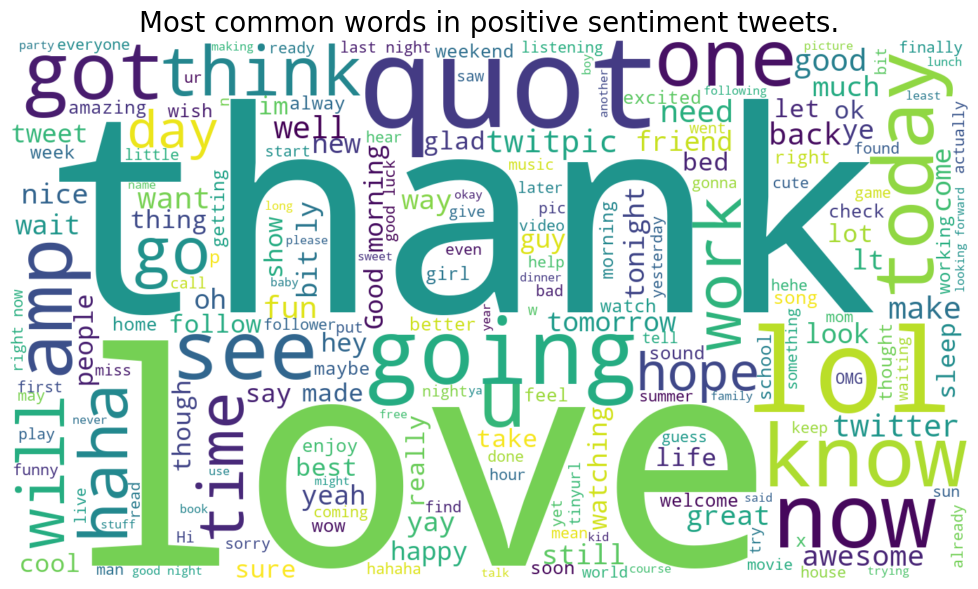

In [22]:
plt.figure(figsize=(14,7))

word_cloud = WordCloud(
    stopwords = STOPWORDS, 
    max_words = 200, 
    width=1366, height=768, 
    background_color="white").generate(" ".join(data[data.target=='Positive'].content))

plt.imshow(word_cloud,interpolation='bilinear')

plt.axis('off')
plt.title('Most common words in positive sentiment tweets.',fontsize=20)
plt.show()

Based on the word cloud, it can be deduced that the most repeated words in tweets with positive sentiment are words such as: `love`, `quot`, `lol`, `haha`, `thank`, `today`.

We generate a similar wordcloud for negative sentiments

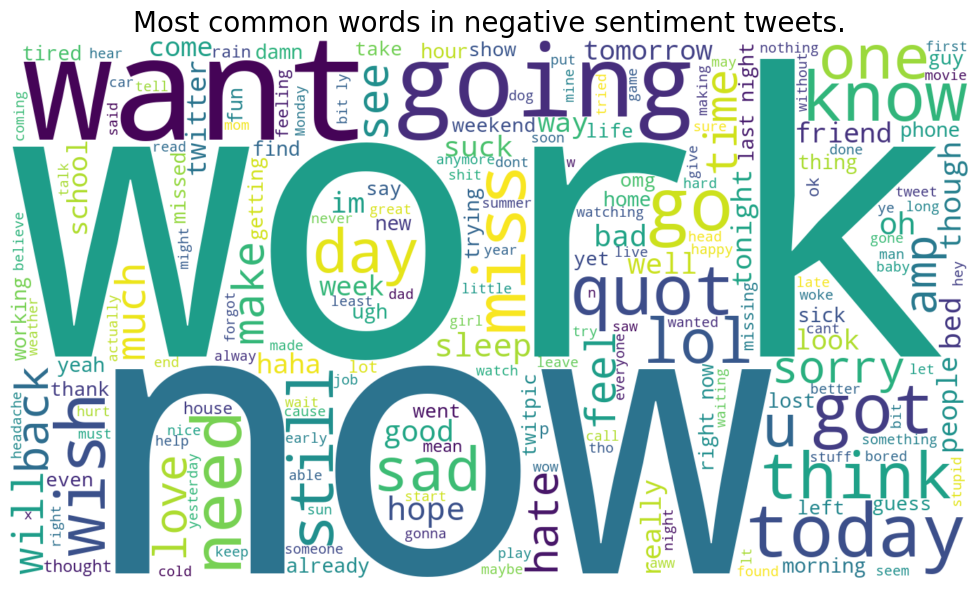

In [23]:
plt.figure(figsize=(14,7))

word_cloud = WordCloud(
    stopwords = STOPWORDS, 
    max_words = 200, 
    width=1366, height=768, 
    background_color="white").generate(" ".join(data[data.target=='Negative'].content))

plt.imshow(word_cloud,interpolation='bilinear')

plt.axis('off')
plt.title('Most common words in negative sentiment tweets.',fontsize=20)

plt.show()

Based on the word cloud, it can be deduced that the most repeated words in tweets with negative sentiment are words such as: `quot`, `lol`, `today` which are the same as for positive sentiment class. 

However, there are also word occurrences from which negative sentiment of a tweet can be inferred such as: `work`, `now`, `sorry` etc.

## Data Preparation

### Dropping unnecessary columns

In this step, we remove extra columns from the dataset. Since our goal is to categorize tweet meanings, only the target and content columns matter. Other columns aren't needed for this analysis and are discarded. This simplification streamlines our focus and makes the data easier to work with.

### Converting Target Labels

In addtion, we transform target labels from text (`Positive` and `Negative`) to numerical values (`1` and `0`). This numeric representation facilitates analysis and modeling processes, enabling the computer to better understand and work with the sentiment categories.

In [24]:
data.drop(['id','date','query','username','length'], axis=1, inplace=True)
data.target = data.target.replace({'Positive': 1, 'Negative': 0})
data.head()

,target,content
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


### Content Cleaning

**Stemming** is a process that aims to **simplify words by reducing them to their base forms**. 


In our project, this is vital as it helps us focus on the core meaning of words, which is essential for sentiment classification. 


For example, words like `Running`, `Runned`, and `Runner` all become `Run` after stemming. 


We've utilized a base of English stopwords and a stemming algorithm from the `NLTK` library to achieve this. We've also defined a regular expression for identifying mentions, links, and non-alphanumeric characters in tweets

In [25]:
#base of english stopwords
english_stopwords = stopwords.words('english')

#stemming algorithm
stemmer = SnowballStemmer('english')

#regex for mentions and links in tweets
regex = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"

### Preprocessing Text

The goal of this function, named preprocess, is to prepare text for analysis by performing several important tasks:

- **Lowercasing and Cleaning**: The function converts text to lowercase and removes non-alphanumeric characters, mentions, and links using the provided regex.


- **Tokenization**: The text is split into individual words, called tokens.


- **Stopword Removal**: Common English stopwords (like 'and,' 'the,' 'is') are removed from the tokens to focus on meaningful content.


- **Stemming** (Optional): If specified, stemming reduces words to their base forms, aiding in meaning extraction.


The function aims to transform raw text into a more structured and relevant format, which is crucial for accurate sentiment analysis.







In [26]:
def preprocess(content, stem=False):
    
    content = re.sub(regex, ' ', str(content).lower()).strip()
    tokens = []
    
    for token in content.split():
        if token not in english_stopwords:
            tokens.append(stemmer.stem(token))
    
    return " ".join(tokens)

In [27]:
data.content = data.content.apply(lambda x: preprocess(x))
data.head()

,target,content
0,0,awww bummer shoulda got david carr third day
1,0,upset updat facebook text might cri result sch...
2,0,dive mani time ball manag save 50 rest go bound
3,0,whole bodi feel itchi like fire
4,0,behav mad see


## Model Preparation

These steps collectively create a data pipeline that transforms raw text into suitable input for the model, making it possible to effectively train and evaluate the sentiment analysis model.

- **Train-Test Split**: The dataset is divided into two sets - training and testing - allowing the model to learn from one set and evaluate its performance on the other.


- **Tokenization**: Text data is converted into sequences of numerical tokens, representing individual words, using a tokenizer. This step is essential for feeding text data into machine learning models.


- **Word Embeddings**: Words are represented as dense vectors using pre-trained word embeddings (like Word2Vec or GloVe). This captures semantic relationships between words and enhances model understanding of text data.


- **Model Compilation**: The model architecture is defined, including layers like LSTM for sequence analysis. The model is compiled with an optimizer, loss function, and evaluation metric, readying it for training.

Let us begin 


### Train test split
Due to the rather large size of the dataset `1,600,000` tweets will be enough for trainnig and testing. We will use `10%` of the data for testing

In [28]:
train, test = train_test_split(data, test_size=0.1, random_state=44)

print('Train dataset shape: {}'.format(train.shape))
print('Test dataset shape: {}'.format(test.shape))

Train dataset shape: (1440000, 2)
Test dataset shape: (160000, 2)


### Tokenization
It is a particular kind of document segmentation. It does breaks up text into smaller chunks or segments called tokens. A tokenizer breaks unstructured data, natural language text, into chunks of information that can be counted as discrete elements. After this operation these counts of token occurences in particular document can be used as a vector representing given document.

In [29]:
tokenizer = Tokenizer()

# fits the tokenizer on the text content from the training dataset (train.content), 
# learning the vocabulary and creating a word-to-index mapping
tokenizer.fit_on_texts(train.content)  
vocab_size = len(tokenizer.word_index) + 1 

max_length = 50

"""
for word, index in list(tokenizer.word_index.items())[:10]:
    print(f'Word: {word}, Index: {index}')
"""

"\nfor word, index in list(tokenizer.word_index.items())[:10]:\n    print(f'Word: {word}, Index: {index}')\n"

Based on the analysis of the tweet length it was concluded that the maximum length for tokenization equal to 50 will be sufficient

### Text Sequence Conversion and Padding

The goal here is to transform the text data into numerical sequences that the model can understand. Ultimately, this process prepares the data for the model, making it compatible for training and evaluation.


- `sequences_train` and `sequences_test` convert the text content of training and testing datasets into sequences of numerical tokens using the tokenizer.


- `X_train` and `X_test` pad these sequences to a fixed length (`max_length`) with zeros, ensuring uniform input size for the model.


- `y_train` and `y_test` store the corresponding sentiment labels from the training and testing datasets.







In [30]:
sequences_train = tokenizer.texts_to_sequences(train.content) 
sequences_test = tokenizer.texts_to_sequences(test.content) 

# padding will be added to the end (or "post") of each sequence.
X_train = pad_sequences(sequences_train, maxlen=max_length, padding='post')
X_test = pad_sequences(sequences_test, maxlen=max_length, padding='post')

y_train = train.target.values
y_test = test.target.values


X_train[0]

array([  157, 12555,    40,   158,   423, 61348,  1197,    38,   178,
          45,   215,    45,  3191,    45,   250,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0])

### Word embeddings using GloVe

Word embeddings provide a dense representation of words and their relative meanings. Embedding Matrix is a maxtrix of all words and their corresponding embeddings. Embedding matrix is used in embedding layer in model to embedded a token into it's vector representation, that contains information regarding that token or word.

Embedding vocabulary is taken from the tokenizer and the corresponding vectors from embedding model, which in this case is `GloVe` model. 


`GloVe` stand for Global Vectors for Word Representation and it is an unsupervised learning algorithm for obtaining vector representations for words. Training is performed on aggregated global word-word co-occurrence statistics from a corpus, and the resulting representations showcase interesting linear substructures of the word vector space.


Below was used pretrained `GloVe` embeddings from world known `Stanford vector files`. The smallest available file contains embeddings created for tiny 6 billions of tokens.


In [ ]:
"""
with open('datasets/glove.6B.100d.txt', encoding='utf-8') as glove_file:
    # Read and print the first 10 lines
    for i, line in enumerate(glove_file):
        if i < 10:
            print(line)
        else:
            break
"""

In [ ]:
embeddings_dictionary = dict()  # store word vectors from the GloVe model
embedding_dim = 100

glove_file = open('datasets/glove.6B.100d.txt', encoding='utf-8')

for line in glove_file:
    records = line.split() # first element is the word, and the subsequent elements are the components of the word vector
    word = records[0]      # get the word
    vector_dimensions = np.asarray(records[1:], dtype='float32') # vector components to a NumPy array
    embeddings_dictionary [word] = vector_dimensions # Stores the word as the key and  vector as the value 
    
glove_file.close()

embeddings_matrix = np.zeros((vocab_size, embedding_dim)) # initializes an empty matrix with dimensions 

# loops through each word in your tokenizer's word index
for word, index in tokenizer.word_index.items():
    # retrieve the pre-trained GloVe vector for the current word
    embedding_vector = embeddings_dictionary.get(word)
    # If a pre-trained vector is found,  it is stored in the corresponding row
    if embedding_vector is not None:
        embeddings_matrix[index] = embedding_vector


### Model Compilation

The proposed model architecture will be tested on the following parameters:

- **loss** = `binnary_crossentropy` (due to binary classification problem)


- **optimizer** = `Adam(learning_rate=0.001)` (may be changed after seeing the learning graph)


- **metrics** = `accuracy` (due to binary classification problem)


- **number of epochs** = `10` (due to the large training data set)


- **batch size** = `1000` (in order to accelerate learning time)

In [33]:
embedding_dim = 100
embeddings_matrix = np.zeros((vocab_size, embedding_dim)) # initializes an empty matrix with dimensions 

embedding_layer = tf.keras.layers.Embedding(
    vocab_size, # number of unique words in the dataset
    embedding_dim, #  dimensionality of the word embeddings
    input_length=max_length, #length of input sequences
    weights=[embeddings_matrix], # initialized with pre-trained word embeddings 
    trainable=False) #  word embeddings should remain fixed during model training and not be updated

In [34]:
num_epochs = 5
batch_size = 1000

## Model Compilation and  Stacked LSTM

Model consisted of layers build with lstm cells. With such a large amount of data, the model is computationally complex making the training process take a while. Furthermore, model regularization layers will reduce the possible overfitting which was present in the simpler models tested.

In [35]:
model = Sequential([
        embedding_layer,
        tf.keras.layers.Bidirectional(LSTM(128, return_sequences=True)), # should return sequences as output
        # Alternative: final output for the entire input sequence. It compresses the sequence information into a single output
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Bidirectional(LSTM(128)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])

In [36]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 50, 100)           26901500  
                                                                 
 bidirectional (Bidirection  (None, 50, 256)           234496    
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 50, 256)           0         
                                                                 
 bidirectional_1 (Bidirecti  (None, 256)               394240    
 onal)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense (Dense)               (None, 64)                1

The objective here is to configure and train the sentiment analysis model: `model.compile()` readies the model for training by specifying the loss function, optimizer, and metrics; `history` holds training information; and `model.fit()` trains the model using prepared data while validating on testing data. 


This process optimizes the model's ability to understand sentiment patterns and evaluate its performance through specified metrics, enhancing its proficiency in sentiment classification.

In [ ]:
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

history = model.fit(
    X_train, 
    y_train, 
    batch_size = batch_size, 
    epochs=num_epochs, 
    validation_data=(X_test, y_test))

Epoch 1/5
 450/1440 [========>.....................] - ETA: 1:29:44 - loss: 0.6931 - accuracy: 0.5006

### Prediction

The prediction step involves utilizing the trained model to make sentiment predictions on new or unseen data. This allows the model to apply what it has learned during training to classify text inputs into specific sentiment categories, providing insights into the sentiment expressed within the text.


In [ ]:
y_pred = model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)

### Classification Report

The goal of a classification report is to provide a comprehensive summary of the model's performance in a classification task. It includes metrics such as precision, recall, F1-score, and support, offering insights into how well the model correctly classifies different classes and handles false positives and false negatives. This report helps assess the model's overall effectiveness and informs decision-making regarding its deployment.

In [ ]:
print(classification_report(y_test, y_pred))

### Visualizing Model Accuracy

The code aims to visualize the training progress and performance of a machine learning model. 


The first plot displays the model's accuracy over epochs for both training and testing data, assisting in assessing how well the model learns from the data. 


The second plot shows the model's loss (error) over epochs for both training and testing data, aiding in understanding how the model's predictions improve. These visualizations help monitor and compare the model's accuracy and loss trends during training, contributing to insights on its training and generalization behavior.

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train accuracy', 'Test accuracy'], loc='lower right')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train loss', 'Test loss'], loc='upper right')
plt.suptitle('Accuracy and loss for second model')
plt.show()

## Conclusions 

In summary, the presented model demonstrated good performance in sentiment analysis, successfully classifying text into different sentiment categories. 


However, a noticeable issue of overfitting is evident, highlighting the need for hyperparameter tuning, particularly adjustments to the learning rate, which might alleviate the overfitting concern. 


Implementing larger dropout layers could also contribute to addressing overfitting. 


Additionally, enhancing the embedding layer complexity, such as utilizing GloVe embeddings with higher dimensions (e.g., 300d), could lead to richer semantic representations, potentially enhancing model comprehension of text nuances. 


It's important to note that achieving high accuracy on the training data remains a challenge, possibly indicating that the training dataset might not be fully representative. 


Further efforts in dataset curation and augmentation could lead to more robust training and improved generalization.